In [81]:
import  pandas as pd
import numpy  as np
cs_ds = pd.read_csv(r'C:\Users\USER\Documents\Datasets\customer_data.csv')

In [82]:
cs_ds.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,OnlineShoppingFrequency,CreditCardUsage,CustomerValueScore
0,1,Male,38,90745,87.14,12,2550.55,0.375
1,2,Female,49,109456,3.11,21,3617.02,0.474
2,3,Male,40,68413,87.60,20,520.69,0.444
3,4,Male,50,112239,53.36,21,1127.19,0.995
4,5,Male,20,57318,93.97,27,3514.72,0.545


In [83]:
import pandas as pd

def missing_values_summarizer(
    df: pd.DataFrame,
    drop_cols: bool = False,
    drop_threshold: float = 0.1,
    verbose: bool = False
):


    if not 0 <= drop_threshold <= 1:
        raise ValueError("drop_threshold must be between 0 and 1.")

    total_rows = len(df)

    missing_counts = df.isna().sum()
    non_missing_counts = df.notna().sum()

    props_df = pd.DataFrame({
        "feature": df.columns,
        "missing_count": missing_counts.values,
        "non_missing_count": non_missing_counts.values,
        "total_vol": total_rows,
        "prop_missing": (missing_counts / total_rows).values,
        "prop_non_missing": (non_missing_counts / total_rows).values,
        "data_type": df.dtypes.values
    }).reset_index(drop=True)

    if drop_cols:
        cols_to_drop = props_df.loc[
            props_df["prop_missing"] > drop_threshold, "feature" ].tolist()

        df_resized = df.drop(columns=cols_to_drop)

        if verbose and cols_to_drop:
            print(f"Dropped columns due to missing threshold ({drop_threshold}): {cols_to_drop}")
    else:
        df_resized = df.copy()

    return props_df, df_resized


In [84]:
prop_miss_df, _ = missing_values_summarizer(cs_ds)
prop_miss_df

,feature,missing_count,non_missing_count,total_vol,prop_missing,prop_non_missing,data_type
0,CustomerID,0,500,500,0.0,1.0,int64
1,Gender,0,500,500,0.0,1.0,object
2,Age,0,500,500,0.0,1.0,int64
3,AnnualIncome,0,500,500,0.0,1.0,int64
4,SpendingScore,0,500,500,0.0,1.0,float64
5,OnlineShoppingFrequency,0,500,500,0.0,1.0,int64
6,CreditCardUsage,0,500,500,0.0,1.0,float64
7,CustomerValueScore,0,500,500,0.0,1.0,float64


In [85]:
cs_dataset = cs_ds.drop(['CustomerID'],
axis=1)

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(cs_dataset,test_size=0.3,random_state=42)

In [87]:
from sklearn.preprocessing import OneHotEncoder
one_hot_enc = OneHotEncoder(drop='first',
                            handle_unknown='ignore')
one_hot_enc.fit(X_train[['Gender']])


X_train_encoded = one_hot_enc.transform(X_train[['Gender']]).toarray()
X_test_encoded = one_hot_enc.transform(X_test[['Gender']]).toarray()

X_train_enc_df = pd.DataFrame( X_train_encoded,
                              columns=one_hot_enc.get_feature_names_out(['Gender'])
)

X_test_enc_df = pd.DataFrame(X_test_encoded,
                             columns=one_hot_enc.get_feature_names_out(['Gender'])
)

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)


X_train = pd.concat([X_train.drop(['Gender'],axis=1),X_train_enc_df],axis=1 )

X_test = pd.concat( [X_test.drop(['Gender'], axis=1),
                     X_test_enc_df],
                       axis=1 )


In [88]:
# from sklearn.preprocessing import StandardScaler

# num_cols = X_train.select_dtypes(include=["number"]).columns

# scaler = StandardScaler()
# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])



In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
X_train.dtypes[X_train.dtypes == "object"]



Series([], dtype: object)

+ Silhouette score – Klasterlərin bir-birindən nə dərəcədə yaxşı ayrıldığını ölçür. Daha yüksək qiymətlər daha aydın sərhədlər deməkdir.

+ Davies–Bouldin indeksi – Klasterlərin sıxlığını və bir-birindən ayrılmasını qiymətləndirir. Daha aşağı qiymətlər daha keyfiyyətli klasterləşməyə işarədir.

+ Calinski–Harabasz skoru – Klasterlərarası dispersiyanı klasterdaxili dispersiya ilə müqayisə edir. Daha yüksək dəyərlər daha yaxşı strukturlaşmış klasterlər deməkdir.

In [91]:
import matplotlib.pyplot as plt

def plot_clustering_metrics(
                            k_vals,
                            sil_scores,
                            davies_scores,
                            cal_hab_scores,
                            x_axis_lbl='Number of clusters (k)',
                            figsize=(10, 15)
                           ):

    _, axes = plt.subplots(3, 1, figsize=figsize)

    axes[0].plot(k_vals, sil_scores, marker='o', color='blue')
    axes[0].set_title('Silhouette Score vs. Number of Clusters (K-means)')
    axes[0].set_xlabel(x_axis_lbl)
    axes[0].set_ylabel('Silhouette Score')
    axes[0].grid(True)

    axes[1].plot(k_vals, davies_scores, marker='o', color='red')
    axes[1].set_title('Davies-Bouldin Index vs. Number of Clusters')
    axes[1].set_xlabel('Number of clusters (K)')
    axes[1].set_ylabel('Davies-Bouldin Index')
    axes[1].grid(True)

    axes[2].plot(k_vals, cal_hab_scores, marker='o', color='green')
    axes[2].set_title('Calinski-Harabasz Score vs. Number of Clusters')
    axes[2].set_xlabel('Number of clusters (K)')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


In [92]:
from sklearn.cluster import KMeans
model = KMeans(random_state=42)


Funksiya prosesi avtomatlaşdırır: K diapazonu üzrə dövr edir, modeli uyğunlaşdırır, qiymətləndirmə skorlarını saxlayır və hər metrikaya əsasən optimal K-ni müəyyənləşdirir. Əgər aktivdirsə, __majority vote__ mexanizmi üç metrikadan gələn nəticələrin ən çox təkrarlananını yekun optimal K kimi təklif edir. Bundan əlavə, vizuallaşdırma seçimi metrikaların qrafik müqayisəsini təqdim edir.

In [93]:
from sklearn.metrics import (
                            silhouette_score,
                            davies_bouldin_score,
                            calinski_harabasz_score
                            )

def find_optimal_clusters(X, model,
                          n_clusters=10,
                          majority_vote=True,
                          visualize=True):

    if not hasattr(model, "fit"):
        raise ValueError("Not a scikit-learn Model")

    k_vals = range(2, n_clusters)
    sil_scores     = []
    davies_scores  = []
    cal_hab_scores = []

    for k in k_vals:
        if hasattr(model, 'n_clusters'):
            model.set_params(n_clusters=k)

        model.fit(X)
        labels = model.labels_ if hasattr(model, "labels_") else model.fit_predict(X)

        sil_scores.append(silhouette_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))
        cal_hab_scores.append(calinski_harabasz_score(X, labels))

    optim_k_silhouette     = k_vals[np.argmax(sil_scores)]
    optim_k_davies_bouldin = k_vals[np.argmin(davies_scores)]
    optim_k_cal_hab        = k_vals[np.argmax(cal_hab_scores)]

    print(f'Optimal cluster based on Silhouette score is:        {optim_k_silhouette}')
    print(f'Optimal cluster based on Davies-Bouldin score is:    {optim_k_davies_bouldin}')
    print(f'Optimal cluster based on Calinski-Harabasz score is: {optim_k_cal_hab}')

    optim_k_comb = None
    if majority_vote:
        candidates = [optim_k_silhouette, optim_k_davies_bouldin, optim_k_cal_hab]
        optim_k_comb = max(set(candidates), key=candidates.count)

    if visualize:
        plot_clustering_metrics(  k_vals,
                                sil_scores=sil_scores,
                                davies_scores=davies_scores,
                                cal_hab_scores=cal_hab_scores
        )

    return (optim_k_comb,
            optim_k_silhouette,
            optim_k_cal_hab,
            optim_k_davies_bouldin)


Funksiyanın mərhələli izahı

1) Klaster keyfiyyətini ölçən üç əsas metrika hesablanır.

2) Funksiya giriş kimi uyğun (unsupervised) model qəbul edir.

3) Müxtəlif K dəyərləri üçün dövr:

+ Model hər K üçün yenidən qurulur (fit edilir).

+ Klaster etiketləri əldə edilir.

+ Hər üç metrika hesablanıb yadda saxlanılır.

4) Optimal K seçimi:

+ Silhouette və Calinski–Harabasz üçün maksimum dəyər seçilir.

+ Davies–Bouldin üçün minimum dəyər seçilir.

5) Majority vote (əgər aktivdirsə):
Üç metrikadan gələn optimal K nəticələrinin ən çox təkrarlananı yekun qərar kimi qəbul edilir.

6) Vizuallaşdırma (əgər aktivdirsə):
Əvvəl yazılmış qrafik funksiyası çağırılır.

7) Nəticə qaytarılır:
Funksiya tuple formatında həm ümumi optimal K-ni, həm də hər metrika üzrə optimal K dəyərlərini qaytarır.

Növbəti mərhələdə bu funksiya təlim və test dəstlərinə tətbiq edilərək klaster performansı müqayisəli şəkildə qiymətləndiriləcək.

Optimal cluster based on Silhouette score is:        7
Optimal cluster based on Davies-Bouldin score is:    9
Optimal cluster based on Calinski-Harabasz score is: 3


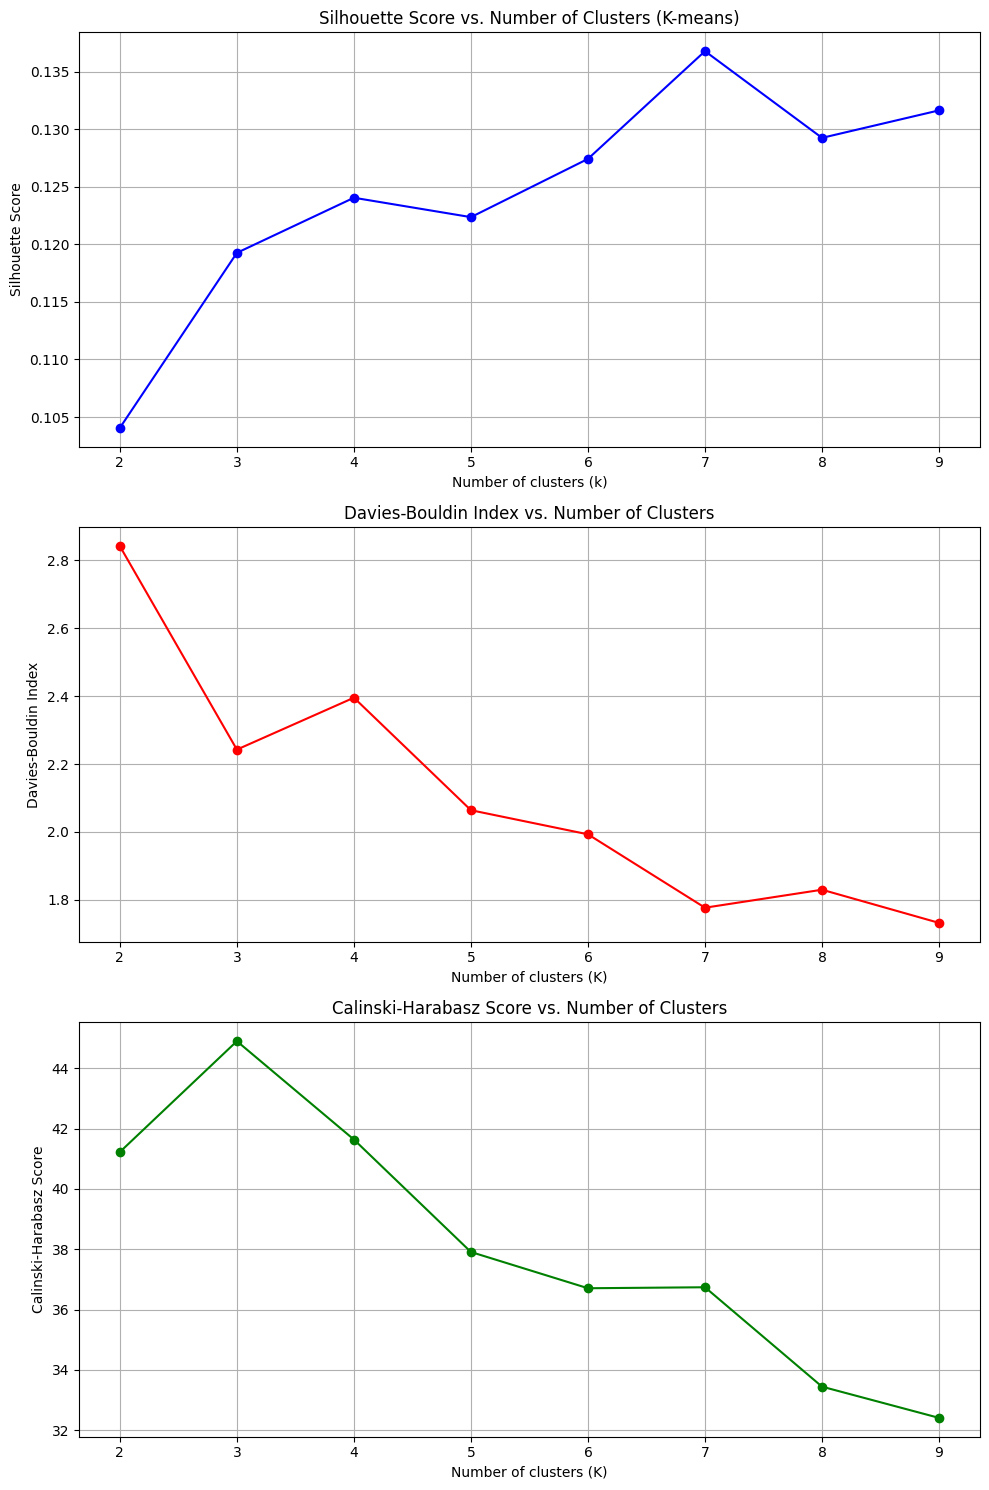

In [94]:
clusters, _, _, _ = find_optimal_clusters(
                                        X=X_train_scaled,
                                        n_clusters=10,
                                        model=model
                                        )


Qrafiklərin təhlili göstərir ki:

+ Silhouette score və Calinski–Harabasz skoru eyni nəticəyə gəlir və optimal klaster sayını 3 kimi göstərir.

+ Davies–Bouldin indeksi isə fərqli K dəyərini təklif edə bilər. Bu, metrikaların müxtəlif struktur xüsusiyyətlərinə həssas olmasından qaynaqlanır.

İki metrika arasında uyğunluq olduğu üçün, çoxluq qərarı (majority vote) nəticəsində 3 klaster seçilir.

In [95]:
model = KMeans(n_clusters=clusters)
kmeans_labels = model.fit_predict(X=X_train_scaled)

# PCA

In [105]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_train_scaled) 
# Bu addımda verilənlər ikiölçülü yeni xüsusiyyət məkanına proyeksiya olunur.

In [106]:
import matplotlib.pyplot as plt
# ikiölçülü scatter qrafik kimi vizuallaşdırır:
def plot_scatter(X, labels, title,
                 title_fsize=14,
                 lab_font_size=12,
                 cmap='winter',
                 axis1=0,
                 axis2=1,
                 scatter_edge_color='k'):

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X[:, axis1], X[:, axis2],
        c=labels, cmap=cmap, s=40,
        edgecolor=scatter_edge_color, alpha=0.7
    )

    plt.colorbar(scatter, label='Cluster/Outlier Labels')
    plt.title(title, fontsize=title_fsize)
    plt.xlabel(f"Feature {axis1+1}", fontsize=lab_font_size)
    plt.ylabel(f"Feature {axis2+1}", fontsize=lab_font_size)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


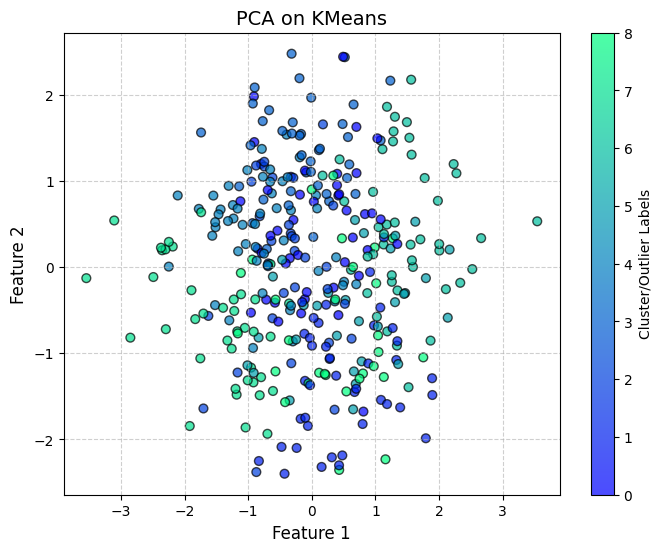

In [107]:
plot_scatter(
    X=reduced_data,
    labels=kmeans_labels,
    title='PCA on KMeans'
)


# Evaluation of performance on testing set

In [108]:
test_cluster_labels = model.predict(X_test_scaled)

test_clusters, _, _, _ = find_optimal_clusters(
    X=X_test_scaled,
    n_clusters=10,
    model=model,
    visualize=False
)


Optimal cluster based on Silhouette score is:        4
Optimal cluster based on Davies-Bouldin score is:    7
Optimal cluster based on Calinski-Harabasz score is: 2


In [110]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

def silhouette_plot(
    X, 
    labels, 
    n_clusters,
    title="Silhouette Plot for Clustering",
    fig_size=(8, 6),
    x_lab='Coefficient Values',
    y_lab='Cluster',
    silh_colors=None,
    x_axis_line_col='black'
):
    # Silhouette dəyərlərini və orta skoru hesablayırıq
    sil_vals = silhouette_samples(X, labels)
    mean_score = silhouette_score(X, labels)

    # Şəkil obyektini yaradırıq
    _, ax = plt.subplots(figsize=fig_size)
    y_lower = 10

    # Rəngləri təyin edirik
    if silh_colors is None:
        silh_colors = plt.cm.tab10.colors

    # Hər klaster üçün siluet sahəsini çəkirik
    for i in range(n_clusters):
        cluster_sil_vals = sil_vals[labels == i]
        cluster_sil_vals.sort()
        y_upper = y_lower + len(cluster_sil_vals)
        colour = silh_colors[i % len(silh_colors)]
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, cluster_sil_vals,
            alpha=0.7,
            color=colour
        )
        # Klaster nömrəsini göstəririk
        ax.text(-0.05, y_lower + 0.5 * len(cluster_sil_vals), str(i))
        y_lower = y_upper + 10

    # Orta silhouette xəttini əlavə edirik
    ax.axvline(x=mean_score, color=x_axis_line_col, linestyle="-")

    # Etiketlər və başlıq
    ax.set_title(title)
    ax.set_xlabel(x_lab)
    ax.set_ylabel(y_lab)
    ax.set_yticks([])

    # Qrid xəttləri
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.show()


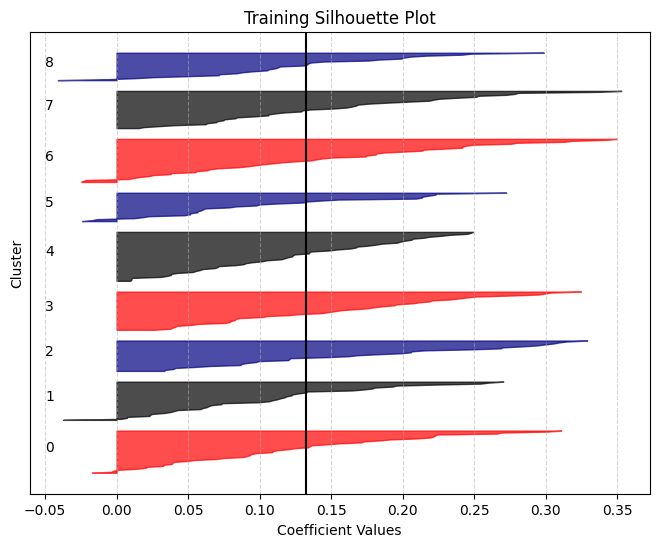

In [111]:
silhouette_plot(
    X_train_scaled,
    kmeans_labels,
    clusters,
    silh_colors=['red', 'black', 'navy'],
    title='Training Silhouette Plot'
)


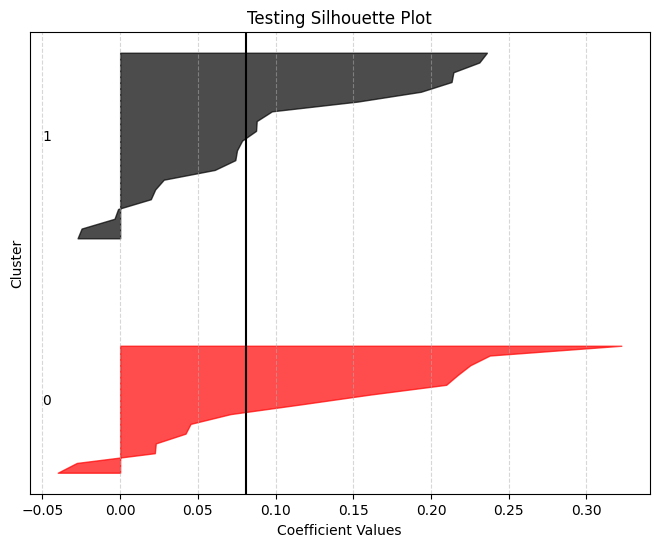

In [112]:
silhouette_plot(
    X_test_scaled,
    labels=test_cluster_labels,
    n_clusters=test_clusters,
    silh_colors=['red', 'black', 'navy'],
    title='Testing Silhouette Plot'
)
